In [ ]:
import pandas as pd
import networkx as nx
import json
from itertools import combinations
from collections import Counter, defaultdict

In [6]:
cuisine_df = pd.read_csv("https://raw.githubusercontent.com/conwayyao/Recipe-Analysis/master/CuisineAnalyzer/cuisinedata/cuisine_data.csv").drop(columns=["Unnamed: 0"])

def parse(x):
    if pd.isna(x) or x == "[]":
        return pd.NA
    if isinstance(x, list):
        return [i.strip().lower() for i in x]
    return list(i.strip().lower().strip("'\"") for i in x.strip("[]").split(", "))

cuisine_df["ingredient_set"] = cuisine_df["ingredients"].apply(parse)
cuisine_df["course_set"] = cuisine_df["course"].apply(parse)
cuisine_df["cuisine_set"] = cuisine_df["cuisine"].apply(parse)
cuisine_df = (
    cuisine_df
    .drop(columns=["ingredients", "course", "cuisine"])
    .rename(columns={
        "ingredient_set": "ingredients",
        "course_set": "course",
        "cuisine_set": "cuisine"
    })
)

cuisine_df = (
    cuisine_df
    .dropna(subset=["ingredients", "course", "cuisine", "totalTimeInSeconds"])
    .drop(columns=["rating"])
    .reset_index(drop=True)
)

def time_group(seconds, group_minutes=10, max_minutes=120):
    minutes = seconds / 60
    if minutes >= max_minutes:
        return "120+ min"
    start = int(minutes // group_minutes) * group_minutes
    end = start + group_minutes - 1
    return f"{start}-{end} min"

cuisine_df["time_group"] = cuisine_df["totalTimeInSeconds"].apply(time_group)
cuisine_df.drop(columns=["totalTimeInSeconds"], inplace=True)

cuisine_df

,id,recipeName,ingredients,course,cuisine,time_group
0,Peanut-butter-fudge-297693,Peanut Butter Fudge,"[country crock® spread, light corn syrup, crea...",[desserts],[american],120+ min
1,Buckeyes-298471,Buckeyes,"[skippy® super chunk® peanut butter, country c...",[desserts],[american],110-119 min
2,Disappearing-buffalo-chicken-dip-297712,Disappearing Buffalo Chicken Dip,"[light mayonnaise, lemon juice, cayenne pepper...",[appetizers],[american],30-39 min
3,Classic-macaroni-salad-304692,Classic Macaroni Salad,"[elbow macaroni, hellmann' or best food real m...","[salads, side dishes]",[american],20-29 min
4,Classic-coleslaw-303481,Classic Coleslaw,"[hellmann' or best food real mayonnais, lemon ...","[salads, side dishes]","[american, southern & soul food]",10-19 min
...,...,...,...,...,...,...
7029,Thai-Coconut-Soup-MyRecipes-246201,Thai Coconut Soup,"[chicken broth, coconut milk, fish sauce, fres...",[soups],"[thai, asian]",40-49 min
7030,Thai-Coconut-Shrimp-Soup-901927,Thai Coconut Shrimp Soup,"[olive oil, large shrimp, carrots, garlic, gin...",[soups],[thai],20-29 min
7031,Spicy-Thai-Lobster-Soup-My-Recipes,Spicy Thai Lobster Soup,"[lobster, vegetable oil, asian, fish, lime rin...","[main dishes, soups]","[asian, thai]",50-59 min
7032,Thai-Green-Papaya-Salad-_Som-Tam_-1266284,Thai Green Papaya Salad (Som Tam),"[fresh lime juice, palm sugar, fish sauce, gar...",[main dishes],"[barbecue, thai]",20-29 min


In [7]:
courses = dict()
cuisines = dict()
tgs = dict()
for _, row in cuisine_df.iterrows():
    for course in row["course"]:
        courses[course] = courses.get(course, 0) + 1
    for cuisine in row["cuisine"]:
        cuisines[cuisine] = cuisines.get(cuisine, 0) + 1
    tgs[row["time_group"]] = tgs.get(row["time_group"], 0) + 1

courses, cuisines, tgs

({'desserts': 611,
  'appetizers': 579,
  'salads': 532,
  'side dishes': 619,
  'condiments and sauces': 290,
  'main dishes': 3523,
  'lunch and snacks': 450,
  'breakfast and brunch': 244,
  'beverages': 175,
  'afternoon tea': 20,
  'breads': 282,
  'soups': 540,
  'cocktails': 58},
 {'american': 942,
  'southern & soul food': 310,
  'french': 323,
  'mexican': 374,
  'southwestern': 203,
  'asian': 1239,
  'kid-friendly': 89,
  'barbecue': 259,
  'cajun & creole': 449,
  'cuban': 221,
  'spanish': 330,
  'irish': 200,
  'italian': 405,
  'mediterranean': 267,
  'hawaiian': 173,
  'chinese': 223,
  'thai': 479,
  'japanese': 378,
  'indian': 257,
  'greek': 539,
  'english': 27,
  'german': 239,
  'hungarian': 297,
  'portuguese': 249,
  'moroccan': 162,
  'swedish': 194},
 {'120+ min': 610,
  '110-119 min': 29,
  '30-39 min': 1227,
  '20-29 min': 1082,
  '10-19 min': 604,
  '80-89 min': 260,
  '40-49 min': 1053,
  '100-109 min': 176,
  '60-69 min': 623,
  '50-59 min': 685,
  '0-9 

Počet receptov použitých na analýzu párov ingrediencií: 5415
Počet kuchýň: 26
Počet výskytov párov ingrediencií: 314940


,recipe_id,kuchyna,ingrediencia_1,ingrediencia_2,par_ingrediencii
0,Peanut-butter-fudge-297693,american,confectioners sugar,country crock® spread,confectioners sugar + country crock® spread
1,Peanut-butter-fudge-297693,american,confectioners sugar,creamy peanut butter,confectioners sugar + creamy peanut butter
2,Peanut-butter-fudge-297693,american,confectioners sugar,light corn syrup,confectioners sugar + light corn syrup
3,Peanut-butter-fudge-297693,american,confectioners sugar,vanilla extract,confectioners sugar + vanilla extract
4,Peanut-butter-fudge-297693,american,country crock® spread,creamy peanut butter,country crock® spread + creamy peanut butter


Počet unikátnych párov ingrediencií: 110553
Súhrn párov ingrediencií:


,par_ingrediencii,celkovy_pocet,pocet_kuchyn,dominantna_kuchyna,pocet_v_dominantnej_kuchyni,specifickost
100209,pepper + salt,705,25,greek,104,0.147518
97346,onions + salt,686,23,hungarian,121,0.176385
96495,olive oil + salt,661,24,greek,138,0.208775
70975,garlic + salt,610,24,greek,85,0.139344
106121,salt + water,414,25,asian,51,0.123188
70719,garlic + onions,405,24,cajun & creole,59,0.145679
70712,garlic + olive oil,402,21,greek,88,0.218905
96250,olive oil + onions,372,21,portuguese,47,0.126344
71929,garlic cloves + salt,365,21,portuguese,54,0.147945
21363,butter + salt,355,21,hungarian,40,0.112676


Počet párov po filtrovaní: 12078


...

Hranica pre zriedkavejšie páry: 6.0
Počet zriedkavejších párov: 4221

Zriedkavejšie, ale kuchynsky špecifické páry:


,par_ingrediencii,celkovy_pocet,pocet_kuchyn,dominantna_kuchyna,pocet_v_dominantnej_kuchyni,specifickost
1046,all-purpose flour + flour tortillas,6,1,mexican,6,1.0
1229,all-purpose flour + low sodium beef broth,6,1,hungarian,6,1.0
1285,all-purpose flour + okra,6,1,cajun & creole,6,1.0
1930,almond flour + unsalted butter,6,1,french,6,1.0
1962,almond meal + granulated sugar,6,1,french,6,1.0
2698,andouille sausage + butter,6,1,cajun & creole,6,1.0
2709,andouille sausage + chicken,6,1,cajun & creole,6,1.0
2719,andouille sausage + chopped celery,6,1,cajun & creole,6,1.0
2793,andouille sausage + jalapeno chilies,6,1,cajun & creole,6,1.0
2808,andouille sausage + low sodium chicken broth,6,1,cajun & creole,6,1.0


Porovnanie častých a zriedkavejších párov:


,skupina,priemerna_specifickost,median_specifickost,priemerny_pocet_kuchyn,median_pocet_kuchyn,pocet_parov
0,časté páry,0.491576,0.431373,7.359310,7.0,3131
1,zriedkavejšie páry,0.638111,0.600000,2.675432,3.0,4221



ŠTATISTICKÉ TESTY
Spearman korelácia medzi frekvenciou páru a špecifickosťou:
rho = -0.247
p-value = 2.7772768713522034e-167

Spearman korelácia medzi frekvenciou páru a počtom kuchýň:
rho = 0.5529
p-value = 0.0

Mann-Whitney U test:
H0: Časté a zriedkavejšie páry majú rovnakú špecifickosť.
H1: Časté páry majú nižšiu špecifickosť ako zriedkavejšie páry.
U = 4315000.5
p-value = 2.974748029008684e-144


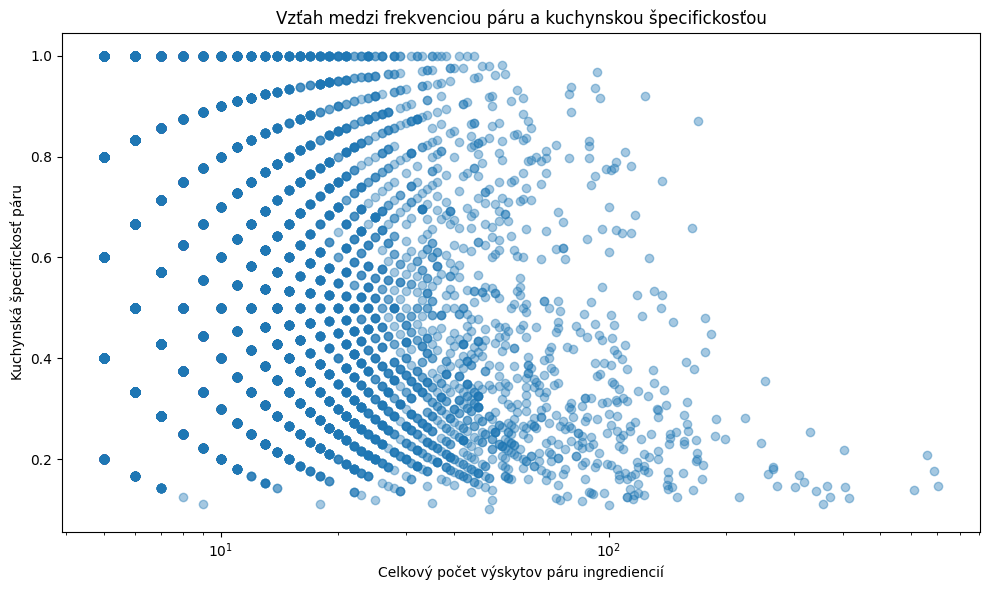

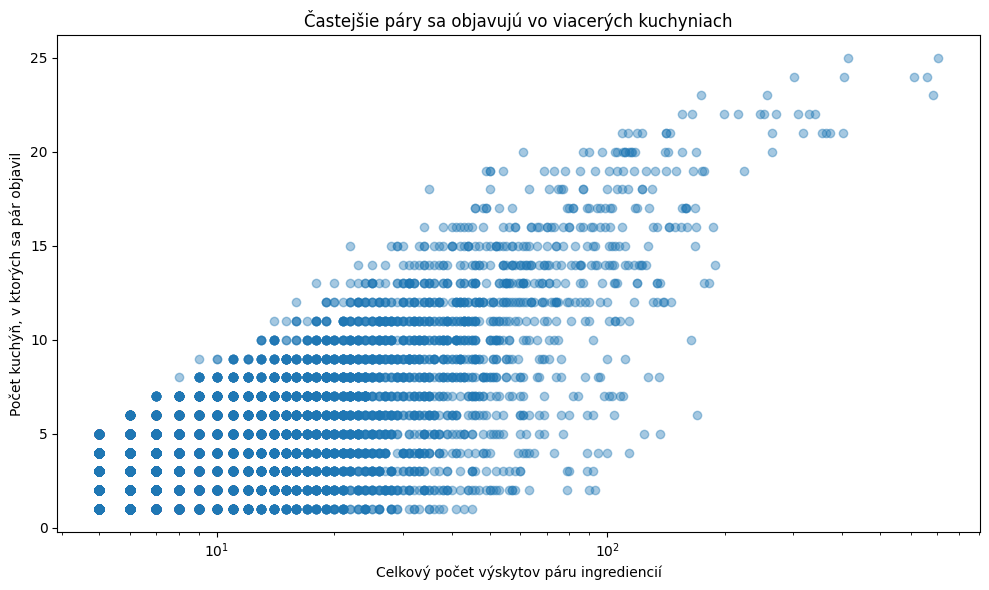

/tmp/ipykernel_1924/2145878271.py:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["časté páry", "zriedkavejšie páry"])


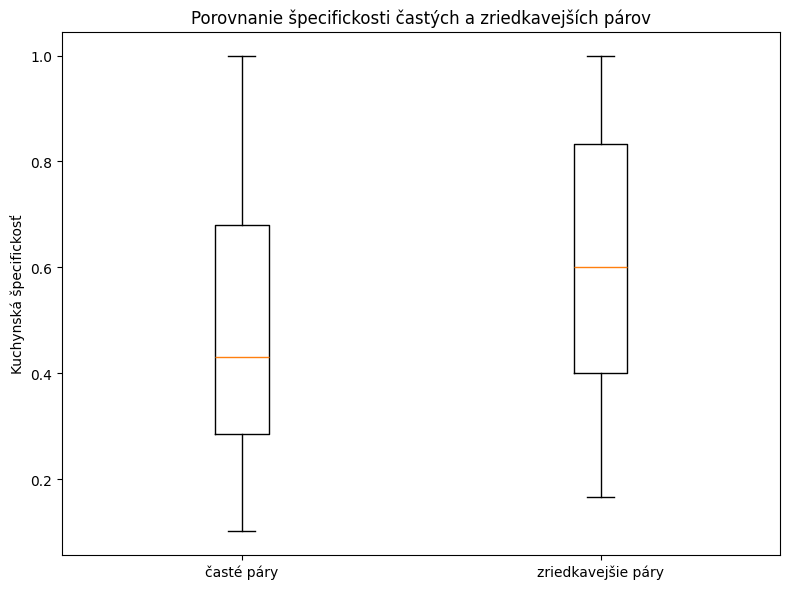


Výstupy boli uložené do priečinka: hypoteza_3_vystupy


,test,statistika,p_value
0,Spearman: frekvencia vs specifickost,-2.469666e-01,2.777277e-167
1,Spearman: frekvencia vs pocet kuchyn,5.529220e-01,0.000000e+00
2,Mann-Whitney: caste pary maju nizsiu specifickost,4.315000e+06,2.974748e-144



INTERPRETÁCIA:

NAJMENEJ ŠPECIFICKÉ PÁRY INGREDIENCIÍ


,par_ingrediencii,celkovy_pocet,pocet_kuchyn,dominantna_kuchyna,pocet_v_dominantnej_kuchyni,specifickost
95881,oil + pepper,49,17,asian,5,0.102041
71474,garlic cloves + ground black pepper,100,18,portuguese,11,0.110000
23867,canola oil + kosher salt,18,13,asian,2,0.111111
23870,canola oil + large eggs,9,9,american,1,0.111111
21363,butter + salt,355,21,hungarian,40,0.112676
78417,ground black pepper + sugar,35,18,asian,4,0.114286
71565,garlic cloves + kosher salt,85,19,italian,10,0.117647
86767,kosher salt + water,50,19,barbecue,6,0.120000
78496,ground black pepper + water,75,18,asian,9,0.120000
49358,crushed red pepper + salt,25,13,asian,3,0.120000



NAJVIAC ŠPECIFICKÉ PÁRY INGREDIENCIÍ


,par_ingrediencii,celkovy_pocet,pocet_kuchyn,dominantna_kuchyna,pocet_v_dominantnej_kuchyni,specifickost
20624,butter + cajun seasoning,45,1,cajun & creole,45,1.0
83854,hungarian paprika + onions,43,1,hungarian,43,1.0
22741,cajun seasoning + olive oil,41,1,cajun & creole,41,1.0
27341,celery + creole seasoning,38,1,cajun & creole,38,1.0
48522,creole seasoning + garlic,37,1,cajun & creole,37,1.0
22824,cajun seasoning + shrimp,36,1,cajun & creole,36,1.0
22513,cajun seasoning + celery,35,1,cajun & creole,35,1.0
94479,mirin + sake,35,1,japanese,35,1.0
70183,garam masala + water,33,1,indian,33,1.0
26799,cayenne pepper + dried thyme,32,1,cajun & creole,32,1.0


In [13]:
# HYPOTÉZA 3:


import pandas as pd
import numpy as np
import itertools
import os
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, mannwhitneyu



df_pairs_base = cuisine_df.copy()


df_pairs_base = df_pairs_base[df_pairs_base["cuisine"].apply(lambda x: isinstance(x, list) and len(x) == 1)].copy()
df_pairs_base["kuchyna"] = df_pairs_base["cuisine"].apply(lambda x: x[0])


df_pairs_base = df_pairs_base[df_pairs_base["ingredients"].apply(lambda x: isinstance(x, list) and len(x) >= 2)].copy()

print("Počet receptov použitých na analýzu párov ingrediencií:", len(df_pairs_base))
print("Počet kuchýň:", df_pairs_base["kuchyna"].nunique())




pair_rows = []

for _, row in df_pairs_base.iterrows():
    recipe_id = row["id"] if "id" in df_pairs_base.columns else row.name
    cuisine = row["kuchyna"]

    ingredients = sorted(set(row["ingredients"]))

    for ing1, ing2 in itertools.combinations(ingredients, 2):
        pair_rows.append({
            "recipe_id": recipe_id,
            "kuchyna": cuisine,
            "ingrediencia_1": ing1,
            "ingrediencia_2": ing2,
            "par_ingrediencii": ing1 + " + " + ing2
        })

pairs_df = pd.DataFrame(pair_rows)

print("Počet výskytov párov ingrediencií:", len(pairs_df))
display(pairs_df.head())




pair_total_counts = (
    pairs_df
    .groupby("par_ingrediencii")
    .size()
    .reset_index(name="celkovy_pocet")
)

print("Počet unikátnych párov ingrediencií:", len(pair_total_counts))




pair_cuisine_counts = (
    pairs_df
    .groupby(["par_ingrediencii", "kuchyna"])
    .size()
    .reset_index(name="pocet_v_kuchyni")
)

pair_stats = pair_cuisine_counts.merge(
    pair_total_counts,
    on="par_ingrediencii",
    how="left"
)


pair_cuisine_number = (
    pair_cuisine_counts
    .groupby("par_ingrediencii")["kuchyna"]
    .nunique()
    .reset_index(name="pocet_kuchyn")
)


dominant_cuisine = (
    pair_stats
    .sort_values(["par_ingrediencii", "pocet_v_kuchyni"], ascending=[True, False])
    .groupby("par_ingrediencii")
    .head(1)
    .rename(columns={
        "kuchyna": "dominantna_kuchyna",
        "pocet_v_kuchyni": "pocet_v_dominantnej_kuchyni"
    })
)

dominant_cuisine = dominant_cuisine[
    [
        "par_ingrediencii",
        "dominantna_kuchyna",
        "pocet_v_dominantnej_kuchyni",
        "celkovy_pocet"
    ]
]

pair_summary = pair_total_counts.merge(
    pair_cuisine_number,
    on="par_ingrediencii",
    how="left"
)

pair_summary = pair_summary.merge(
    dominant_cuisine,
    on=["par_ingrediencii", "celkovy_pocet"],
    how="left"
)


pair_summary["specifickost"] = (
    pair_summary["pocet_v_dominantnej_kuchyni"] /
    pair_summary["celkovy_pocet"]
)

pair_summary = pair_summary.sort_values(
    ["celkovy_pocet", "specifickost"],
    ascending=[False, True]
)

print("Súhrn párov ingrediencií:")
display(pair_summary.head(20))




min_pair_count = 5

pair_summary_filtered = pair_summary[
    pair_summary["celkovy_pocet"] >= min_pair_count
].copy()

print("Počet párov po filtrovaní:", len(pair_summary_filtered))
display(pair_summary_filtered.head())




frequent_threshold = pair_summary_filtered["celkovy_pocet"].quantile(0.75)

frequent_pairs = pair_summary_filtered[
    pair_summary_filtered["celkovy_pocet"] >= frequent_threshold
].copy()

print("Hranica pre časté páry:", frequent_threshold)
print("Počet častých párov:", len(frequent_pairs))

print("\nNajčastejšie páry ingrediencií:")
display(
    frequent_pairs
    .sort_values("celkovy_pocet", ascending=False)
    .head(30)
)




rare_threshold = pair_summary_filtered["celkovy_pocet"].quantile(0.25)

rare_pairs = pair_summary_filtered[
    pair_summary_filtered["celkovy_pocet"] <= rare_threshold
].copy()

print("Hranica pre zriedkavejšie páry:", rare_threshold)
print("Počet zriedkavejších párov:", len(rare_pairs))

print("\nZriedkavejšie, ale kuchynsky špecifické páry:")
display(
    rare_pairs
    .sort_values(["specifickost", "celkovy_pocet"], ascending=[False, False])
    .head(30)
)




comparison_df = pd.DataFrame({
    "skupina": [
        "časté páry",
        "zriedkavejšie páry"
    ],
    "priemerna_specifickost": [
        frequent_pairs["specifickost"].mean(),
        rare_pairs["specifickost"].mean()
    ],
    "median_specifickost": [
        frequent_pairs["specifickost"].median(),
        rare_pairs["specifickost"].median()
    ],
    "priemerny_pocet_kuchyn": [
        frequent_pairs["pocet_kuchyn"].mean(),
        rare_pairs["pocet_kuchyn"].mean()
    ],
    "median_pocet_kuchyn": [
        frequent_pairs["pocet_kuchyn"].median(),
        rare_pairs["pocet_kuchyn"].median()
    ],
    "pocet_parov": [
        len(frequent_pairs),
        len(rare_pairs)
    ]
})

print("Porovnanie častých a zriedkavejších párov:")
display(comparison_df)




spearman_spec = spearmanr(
    pair_summary_filtered["celkovy_pocet"],
    pair_summary_filtered["specifickost"]
)

spearman_cuisines = spearmanr(
    pair_summary_filtered["celkovy_pocet"],
    pair_summary_filtered["pocet_kuchyn"]
)

mann_spec = mannwhitneyu(
    frequent_pairs["specifickost"],
    rare_pairs["specifickost"],
    alternative="less"
)

print("\nŠTATISTICKÉ TESTY")
print("Spearman korelácia medzi frekvenciou páru a špecifickosťou:")
print("rho =", round(spearman_spec.statistic, 4))
print("p-value =", spearman_spec.pvalue)

print("\nSpearman korelácia medzi frekvenciou páru a počtom kuchýň:")
print("rho =", round(spearman_cuisines.statistic, 4))
print("p-value =", spearman_cuisines.pvalue)

print("\nMann-Whitney U test:")
print("H0: Časté a zriedkavejšie páry majú rovnakú špecifickosť.")
print("H1: Časté páry majú nižšiu špecifickosť ako zriedkavejšie páry.")
print("U =", round(mann_spec.statistic, 4))
print("p-value =", mann_spec.pvalue)



os.makedirs("hypoteza_3_vystupy", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.scatter(
    pair_summary_filtered["celkovy_pocet"],
    pair_summary_filtered["specifickost"],
    alpha=0.4
)
plt.xscale("log")
plt.xlabel("Celkový počet výskytov páru ingrediencií")
plt.ylabel("Kuchynská špecifickosť páru")
plt.title("Vzťah medzi frekvenciou páru a kuchynskou špecifickosťou")
plt.tight_layout()
plt.savefig("hypoteza_3_vystupy/frekvencia_vs_specifickost.png", dpi=300)
plt.show()



plt.figure(figsize=(10, 6))
plt.scatter(
    pair_summary_filtered["celkovy_pocet"],
    pair_summary_filtered["pocet_kuchyn"],
    alpha=0.4
)
plt.xscale("log")
plt.xlabel("Celkový počet výskytov páru ingrediencií")
plt.ylabel("Počet kuchýň, v ktorých sa pár objavil")
plt.title("Častejšie páry sa objavujú vo viacerých kuchyniach")
plt.tight_layout()
plt.savefig("hypoteza_3_vystupy/frekvencia_vs_pocet_kuchyn.png", dpi=300)
plt.show()



plot_data = [
    frequent_pairs["specifickost"],
    rare_pairs["specifickost"]
]

plt.figure(figsize=(8, 6))
plt.boxplot(plot_data, labels=["časté páry", "zriedkavejšie páry"])
plt.ylabel("Kuchynská špecifickosť")
plt.title("Porovnanie špecifickosti častých a zriedkavejších párov")
plt.tight_layout()
plt.savefig("hypoteza_3_vystupy/boxplot_specifickost.png", dpi=300)
plt.show()



pairs_df.to_csv(
    "hypoteza_3_vystupy/vsetky_pary_ingrediencii.csv",
    index=False,
    encoding="utf-8-sig"
)

pair_summary.to_csv(
    "hypoteza_3_vystupy/suhrn_parov_ingrediencii.csv",
    index=False,
    encoding="utf-8-sig"
)

pair_summary_filtered.to_csv(
    "hypoteza_3_vystupy/suhrn_parov_ingrediencii_filtrovane.csv",
    index=False,
    encoding="utf-8-sig"
)

frequent_pairs.to_csv(
    "hypoteza_3_vystupy/caste_pary.csv",
    index=False,
    encoding="utf-8-sig"
)

rare_pairs.to_csv(
    "hypoteza_3_vystupy/zriedkavejsie_pary.csv",
    index=False,
    encoding="utf-8-sig"
)

comparison_df.to_csv(
    "hypoteza_3_vystupy/porovnanie_caste_zriedkave_pary.csv",
    index=False,
    encoding="utf-8-sig"
)

test_results_df = pd.DataFrame({
    "test": [
        "Spearman: frekvencia vs specifickost",
        "Spearman: frekvencia vs pocet kuchyn",
        "Mann-Whitney: caste pary maju nizsiu specifickost"
    ],
    "statistika": [
        spearman_spec.statistic,
        spearman_cuisines.statistic,
        mann_spec.statistic
    ],
    "p_value": [
        spearman_spec.pvalue,
        spearman_cuisines.pvalue,
        mann_spec.pvalue
    ]
})

test_results_df.to_csv(
    "hypoteza_3_vystupy/statisticke_testy.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nVýstupy boli uložené do priečinka: hypoteza_3_vystupy")
display(test_results_df)




print("\nINTERPRETÁCIA:")







najmenej_specificke_pary = (
    pair_summary_filtered
    .sort_values(
        ["specifickost", "pocet_kuchyn", "celkovy_pocet"],
        ascending=[True, False, False]
    )
    .head(15)
)

print("\nNAJMENEJ ŠPECIFICKÉ PÁRY INGREDIENCIÍ")
display(najmenej_specificke_pary)



najviac_specificke_pary = (
    pair_summary_filtered
    .sort_values(
        ["specifickost", "celkovy_pocet"],
        ascending=[False, False]
    )
    .head(15)
)

print("\nNAJVIAC ŠPECIFICKÉ PÁRY INGREDIENCIÍ")

display(najviac_specificke_pary)


najmenej_specificke_pary.to_csv(
    "hypoteza_3_vystupy/najmenej_specificke_pary.csv",
    index=False,
    encoding="utf-8-sig"
)

najviac_specificke_pary.to_csv(
    "hypoteza_3_vystupy/najviac_specificke_pary.csv",
    index=False,
    encoding="utf-8-sig"
)
